# Qualtran Syntactic Sugar

This notebook shows how we can layer on a level (level 3, L3) of syntactic sugar on top of the ordinary Qualtran data model (level 2, L2). Compiling down to a fixed, serialized form is level 1, L1.

In [1]:
# Top-level qualtran imports
import qualtran as qlt
import qualtran.dtype as qdt

## Negate

We'll use the overloaded operators on quantum variables as an introductory example of how to define a quantum subroutine using L3 syntactic sugar. 

 - We define an ordinary function that takes in the quantum variable `x`. This function can take arbitrary classical compile-time parameters as well.
 - The function takes a bloq-builder as its first argument. This is currently required, although I may make it optional. It's usually helpful to pass along if you need to allocate new quantum variables. Here, it's unused.
 - The `bloq` decorator is required to record calls to this function as quantum subroutine calls.
 - The `~` operator performs a bitwise NOT.
 - The `+=` operator with a compile-time classical right-hand argument performs a quantum-classical addition `AddK`.
 - The function must must return a string-keyed dictionary. The keys set the output register names.

In [2]:
from qualtran.l3 import bloqify

@bloqify
def negate(bb, x):
    x = ~x
    x += 1
    return {'x': x}

### Instantiating `negate`.

In (ordinary) Qualtran-L2, we're used to instantiating bloq objects. In Qualtran-L3 we have these functions, which can be called from other functions. If you'd like a bloq object, you must provide the missing information, namely the quantum signature specifying the input and output quantum data types.

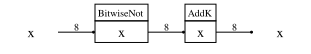

x_out = (-5,)


In [3]:
negate_bloq = negate.make(qlt.Signature.build(x=qdt.QInt(8)))
qlt.show_bloq(negate_bloq)
print('x_out =', negate_bloq.call_classically(x=5))

### Calling `negate` from L2

In (ordinary) Qualtran-L2, you use a bloq builder to wire up programs. The syntactic sugar functions are fully compatible with `BloqBuilder`.
 - The `BloqBuilder` class has learned some new methods that make common operations easier. `bb.alloc_qint` adds a `IntState` bloq under-the-hood.
 - **TODO** this is broken because of `IntState` using unsigned integers.

In [4]:
# Make our own bloq builder
bb = qlt.BloqBuilder()

# Allocate the number "5" and call "negate" on it
five = bb.alloc_qint(5, bitsize=8)
negate_out = negate(bb, x=five)

# Finish building; wire-up outputs.
program = bb.finalize(neg_five=negate_out)

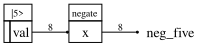

neg_five = (251,)


In [5]:
qlt.show_bloq(program)
print("neg_five =", program.call_classically())

## Building `negate` from the ground up

When we used the operators `~` and `+=`, we used bloqs from the standard library (namely `BitwiseNot` and `AddK`) to build our program. For illustrative purposes, we'll implement all the callees of a negate subroutine from a lower instruction set. We'll restrict ourselves to:

 - `qualtran.bloqs.arithmetic.Add` quantum-quantum adder
 - `qualtran.bloqs.basic_gates.XGate` the single-qubit X (NOT) gate.

In [6]:
# We'll use these for type annotations
from qualtran import BloqBuilder, QVar

### `xor_k`

This bloq does $x \oplus k$ for quantum $x$ and classical $k$. Specifically: it flips bits in `x` according to the bit-encoding of the classical compile-time integer `k`.

 - We use `x[:]` to split e.g. a quantum integer into its individual qubits.
 - We use `x.dtype` to write generic code without boilerplate. Here, we use `x.dtype` to turn the classical integer `k` into bits.
 - We use the `~q` operator on individual qubits (i.e. `QVar` with `dtype=QBit()`). The operator knows to use `qualtran.bloqs.basic_gates.XGate`.

In [7]:
@bloqify
def xor_k(bb: 'BloqBuilder', x: 'QVar', k: int):
    """XOR the classical value `k` into the `x` register."""
    xs = x[:]
    for i, bit in enumerate(x.dtype.to_bits(k)):
        if bit == 1:
            xs[i] = ~xs[i]

    return {'x': bb.join(xs, dtype=x.dtype)}

### `bitwise_not`

This bloq does $X$ to each qubit. 

 - We implicitly split the qubits. The `x` qvar will call split once, and subsequent index access will give you the results of the split operation.
 - We could have used `~` again, but library functions can also be provided by little wrapper functions, here: `xgate`. These just delegate to `XGate.qcall(...)`, which we'll discuss later; but they look nicer.

In [8]:
@bloqify
def bitwise_not(bb: 'BloqBuilder', x: 'QVar'):
    from qualtran.l3.tracing_bloqs import xgate

    outs = []
    for i in range(len(x)):
        out = xgate(x[i])
        outs.append(out)

    return {'x': bb.join(outs)}

### `add_k`

This bloq adds a constant by loading it into a register with clifford operations and performing a quantum-quantum addition.

 - We use our previously-defined `xor_k` function. You can see that you call it like normal.
 - We're using `Add` from the standard library. Bloqs can learn a new classmethod `qcall` which takes both quantum variables and classical compile-time parameters to instantiate a bloq object and add it to the program. Here, `Add.qcall` knows how to deduce the two data types from the quantum variables; and it can extract the `bb` object from within the quantum variables. 

In [9]:
@bloqify
def add_k(bb: 'BloqBuilder', x: 'QVar', k: int):
    from qualtran.bloqs.arithmetic import Add

    # load `k`
    qk = bb.allocate(dtype=x.dtype)
    qk = xor_k(bb, x=qk, k=k)

    # Add
    qk, x = Add.qcall(a=qk, b=x)

    # unload `k`
    qk = xor_k.adjoint(bb, x=qk, k=k)
    bb.free(qk)

    return {'x': x}

### Negate

We put things together in the same way, calling our functions we defined above.

In [10]:
@bloqify
def negate(bb: 'BloqBuilder', x: 'QVar'):
    x = bitwise_not(bb, x=x)
    x = add_k(bb, x=x, k=1)
    return {'x': x}

### Instantiating

This is the same as before. To get a bloq object, we need to give the overall signature, while all subsequent callees deduce data types from the quantum variables that get passed from callers.

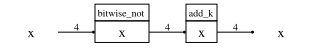

In [11]:
bloq = negate.make(qlt.Signature.build(x=qdt.QInt(4)))
qlt.show_bloq(bloq)

### Call graph

The call graph looks like what we expect. 

Whereas the built-in `AddK` bloq can override its callgraph, declare its tensors, and be queried for its compile-time classical parameters; these bloq objects are all named instantiations of the `CompositeBloq` container class, which can be limiting. To promote
an L3 `@bloq` function to its own `Bloq` class, I'll show that somewhere else.

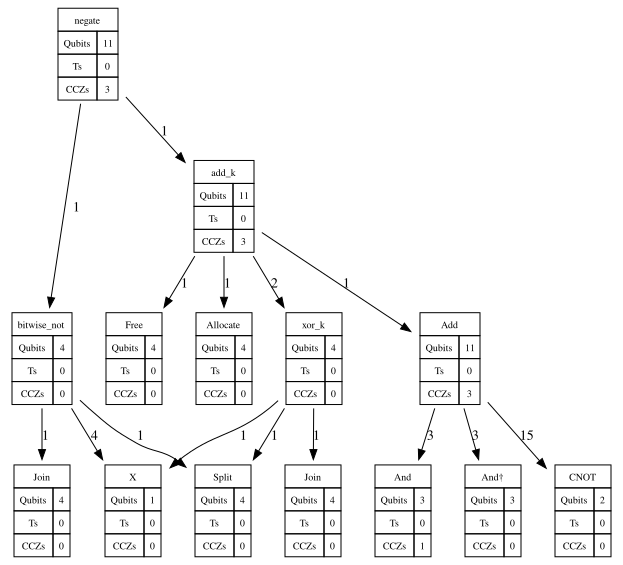

In [12]:
from qualtran.drawing import show_call_graph
show_call_graph(bloq, agg_gate_counts='t_and_ccz')

### Circuit

Here, we do one level of flattening, showing the interior of `bitwise_not` and `add_k`

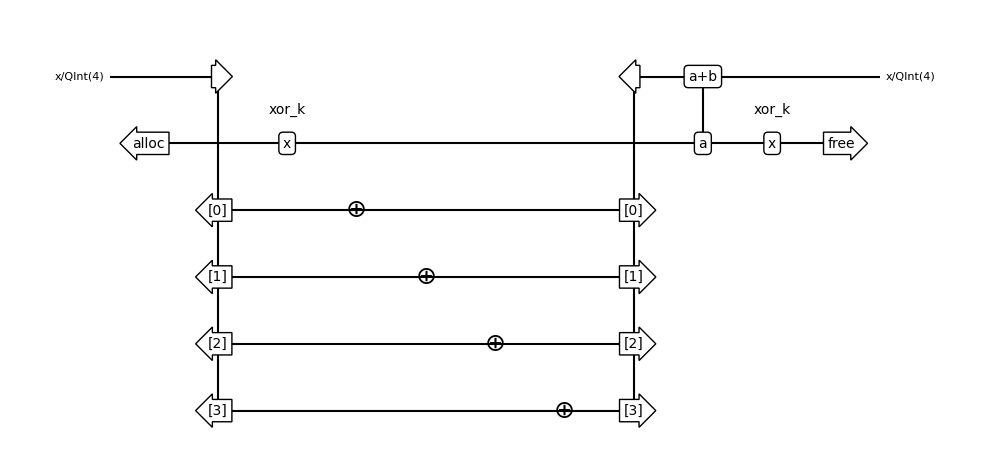

In [13]:
from qualtran.bloqs.arithmetic import Add
flat = bloq.flatten_once()
qlt.show_bloq(flat, 'musical_score')